Found 3708 images belonging to 19 classes.
Found 921 images belonging to 19 classes.
Epoch 1/10
116/116 [==============================] - 1058s 9s/step - loss: 0.5241 - accuracy: 0.9145 - val_loss: 0.0460 - val_accuracy: 0.9967
Epoch 2/10
116/116 [==============================] - 114s 986ms/step - loss: 0.0241 - accuracy: 0.9984 - val_loss: 0.0171 - val_accuracy: 0.9989
Epoch 3/10
116/116 [==============================] - 114s 980ms/step - loss: 0.0115 - accuracy: 0.9995 - val_loss: 0.0111 - val_accuracy: 0.9989
Epoch 4/10
116/116 [==============================] - 114s 980ms/step - loss: 0.0066 - accuracy: 1.0000 - val_loss: 0.0103 - val_accuracy: 1.0000
Epoch 5/10
116/116 [==============================] - 114s 985ms/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.0068 - val_accuracy: 1.0000
Epoch 6/10
116/116 [==============================] - 115s 988ms/step - loss: 0.0042 - accuracy: 0.9997 - val_loss: 0.0051 - val_accuracy: 1.0000
Epoch 7/10
116/116 [=====================

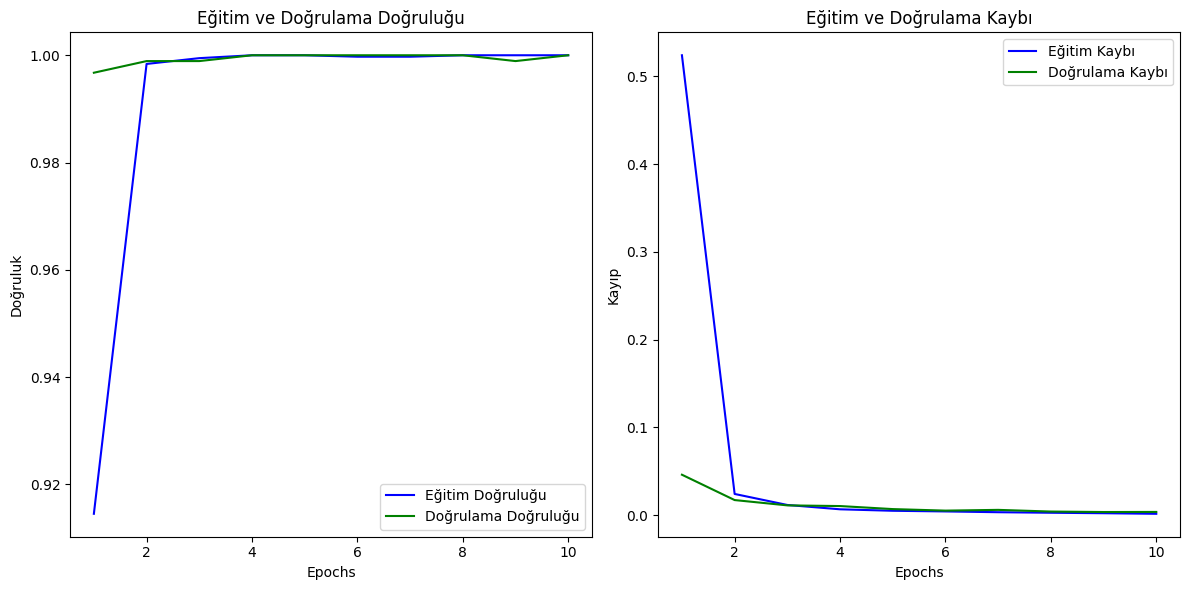

1/1 [==============================] - 1s 1s/step
[[0.0050022  0.00230048 0.00427535 0.00318518 0.03318908 0.02589262
  0.20056868 0.01159167 0.0012062  0.00456054 0.01228439 0.00067876
  0.00478067 0.01996833 0.00142349 0.6543961  0.0018251  0.01036701
  0.00250414]]


In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class AnimalDetectionModel:
    def __init__(self, num_classes, input_shape=(224, 224, 3)):
        """
        Hayvan tanıma modeli için sınıf yapıcısı.

        Args:
            num_classes (int): Tanınacak hayvan sınıfı sayısı
            input_shape (tuple): Girdi görüntü boyutları
        """
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.model = self._build_model()

    def _build_model(self):
        """
        Transfer öğrenme kullanarak MobileNetV2 tabanlı model oluşturur.

        Returns:
            tf.keras.Model: Eğitilmeye hazır derin öğrenme modeli
        """
        # Temel MobileNetV2 modelini yükle
        base_model = MobileNetV2(
            weights='imagenet',
            include_top=False,
            input_shape=self.input_shape
        )

        # Tüm katmanları dondur
        base_model.trainable = False

        # Yeni sınıflandırıcı katmanları ekle
        x = base_model.output
        x = GlobalAveragePooling2D()(x)
        x = Dense(1024, activation='relu')(x)
        output = Dense(self.num_classes, activation='softmax')(x)

        model = Model(inputs=base_model.input, outputs=output)
        return model

    def prepare_data(self, data_dir, test_size=0.2, batch_size=32):
        """
        Görüntü verilerini hazırlar ve ayırır.

        Args:
            data_dir (str): Eğitim görüntülerinin dizini
            test_size (float): Test verisi oranı
            batch_size (int): Toplu işlem boyutu

        Returns:
            tuple: Eğitim ve test veri üreteçleri
        """
        # Veri artırma
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            validation_split=test_size
        )

        # Eğitim ve doğrulama veri üreteçleri
        train_generator = train_datagen.flow_from_directory(
            data_dir,
            target_size=self.input_shape[:2],
            batch_size=batch_size,
            class_mode='categorical',
            subset='training'
        )

        validation_generator = train_datagen.flow_from_directory(
            data_dir,
            target_size=self.input_shape[:2],
            batch_size=batch_size,
            class_mode='categorical',
            subset='validation'
        )

        return train_generator, validation_generator

    def train(self, train_generator, validation_generator, epochs=10):
        """
        Modeli eğitir.

        Args:
            train_generator: Eğitim veri üreteçi
            validation_generator: Doğrulama veri üreteçi
            epochs (int): Eğitim epoch sayısı
        """
        # Modeli derle
        self.model.compile(
            optimizer=Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Modeli eğit
        history = self.model.fit(
            train_generator,
            epochs=epochs,
            validation_data=validation_generator
        )

        return history

    def predict(self, image_path):
        """
        Tek bir görüntü için tahmin yapar.

        Args:
            image_path (str): Görüntü dosya yolu

        Returns:
            list: Tahmin edilen sınıflar ve olasılıkları
        """
        # Görüntüyü yükle ve ön işleme
        img = image.load_img(image_path, target_size=self.input_shape[:2])
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        # Tahmin
        predictions = self.model.predict(img_array)
        return predictions

    def save_model(self, path='animal_detection_model.h5'):
        """Modeli kaydeder."""
        self.model.save(path)

    def load_model(self, path='animal_detection_model.h5'):
        """Kaydedilmiş modeli yükler."""
        self.model = tf.keras.models.load_model(path)

import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Eğitim sürecinden elde edilen doğruluk ve kayıp değerlerini görselleştirir.

    Args:
        history: Modelin eğitim geçmişi
    """
    # Doğruluk ve doğrulama doğruluğu
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    # Kayıp ve doğrulama kaybı
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Epoch sayısı
    epochs = range(1, len(acc) + 1)

    # Doğruluk grafiği
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Eğitim Doğruluğu')
    plt.plot(epochs, val_acc, 'g-', label='Doğrulama Doğruluğu')
    plt.title('Eğitim ve Doğrulama Doğruluğu')
    plt.xlabel('Epochs')
    plt.ylabel('Doğruluk')
    plt.legend()

    # Kayıp grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Eğitim Kaybı')
    plt.plot(epochs, val_loss, 'g-', label='Doğrulama Kaybı')
    plt.title('Eğitim ve Doğrulama Kaybı')
    plt.xlabel('Epochs')
    plt.ylabel('Kayıp')
    plt.legend()

    plt.tight_layout()
    plt.show()

def main():
    # Örnek kullanım
    num_classes = 19  # Tanınacak hayvan sınıfı sayısı
    data_directory = '/content/drive/MyDrive/Animal1'

    # Model oluştur
    animal_model = AnimalDetectionModel(num_classes)

    # Verileri hazırla
    train_gen, val_gen = animal_model.prepare_data(data_directory)

    # Modeli eğit
    history = animal_model.train(train_gen, val_gen)

    # Eğitim geçmişini görselleştir
    plot_training_history(history)

    # Modeli kaydet
    animal_model.save_model()

    # Tek bir görüntü için tahmin
    test_image = '/content/drive/MyDrive/00000-1285649098.png'
    predictions = animal_model.predict(test_image)
    print(predictions)

if __name__ == "__main__":
    main()


In [11]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Model ve veri yollarını ayarlayın
model_path = "/content/animal_detection_model.h5"  # H5 formatındaki model dosyasının yolu
image_folder = "/content/drive/MyDrive/hayvanlar"  # Tahmin yapılacak görüntülerin olduğu klasör
target_size = (224, 224)  # Modelin beklediği giriş boyutu

# Modeli yükle
print("Model yükleniyor...")
model = load_model(model_path)
print("Model başarıyla yüklendi!")

# Klasördeki görüntüleri tahmin etme
def predict_images_from_folder(model, folder_path, target_size):
    class_names = [str(i) for i in range(model.output_shape[-1])]  # Sınıf isimlerini ayarla

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            # Görüntüyü yükle ve ölçeklendir
            img = load_img(file_path, target_size=target_size)
            img_array = img_to_array(img) / 255.0  # Normalizasyon
            img_array = np.expand_dims(img_array, axis=0)  # Batch boyutu ekle

            # Tahmin yap
            predictions = model.predict(img_array)
            predicted_class = np.argmax(predictions, axis=-1)[0]  # En yüksek olasılığı al

            print(f"Tahmin Sonuçları ({filename}): {predictions}")
            print(f"Tahmin Edilen Sınıf: {class_names[predicted_class]}\n")

# Tahmin fonksiyonunu çağır
predict_images_from_folder(model, image_folder, target_size)



Model yükleniyor...
Model başarıyla yüklendi!


1/1 [==============================] - 1s 741ms/step
Tahmin Sonuçları (1.jpg): [[0.02768181 0.04294708 0.00753043 0.00502063 0.38159874 0.00453113
  0.11545541 0.00592934 0.02307004 0.00249757 0.00663845 0.06321268
  0.21162301 0.04995781 0.00717988 0.00897815 0.00641944 0.02225953
  0.00746887]]
Tahmin Edilen Sınıf: 4

1/1 [==============================] - 0s 48ms/step
Tahmin Sonuçları (2.jpg): [[9.9682343e-01 3.6361147e-04 1.1315078e-04 7.6139113e-05 1.1156314e-04
  3.4957600e-05 4.2459174e-04 1.3839362e-04 4.2443789e-04 6.9219054e-06
  4.1122727e-05 5.5112268e-05 1.0293775e-04 2.5895421e-05 1.4757377e-04
  1.3477427e-04 9.0240319e-05 1.5824896e-04 7.2685961e-04]]
Tahmin Edilen Sınıf: 0

1/1 [==============================] - 0s 52ms/step
Tahmin Sonuçları (3.jpg): [[0.06766823 0.01563983 0.06442451 0.00733136 0.4148013  0.03461567
  0.01213037 0.00174551 0.0626532  0.01090861 0.0979932  0.11319237
  0.01362425 0.01453102 0.00514454 0.01298139 0.00582425 0.00865524
  0.03613514]]
Tah